In [1]:
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import arviz as az

try:
    from matplotlib import font_manager
    font_manager.fontManager.addfont('/usr/share/fonts/truetype/msttcorefonts/Arial.ttf')
    prop = font_manager.FontProperties(fname='/usr/share/fonts/truetype/msttcorefonts/Arial.ttf')
    plt.rcParams['font.family'] = 'sans-serif'
    plt.rcParams['font.sans-serif'] = prop.get_name()
except Exception as e:
    print('Could not load Arial font')
    print(e)

# Change this pattern to your files
files = sorted(glob.glob("dl_evol_run_*.csv"))

print(f"Found {len(files)} chains")

chains = []

for f in files:
    df = pd.read_csv(f)
    chains.append(df.iloc[:, 0].to_numpy())   # first column = description length

# R-hat requires equal chain lengths
n = min(len(c) for c in chains)
chains = np.array([c[:n] for c in chains])

print("Chain shape:", chains.shape)

# Compute split-Rhat
idata = az.convert_to_inference_data(chains)
rhat = az.rhat(idata)

print(rhat)

/home/oriolca/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "
/home/oriolca/.local/lib/python3.10/site-packages/arviz/__init__.py:50: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(


Found 5 chains
Chain shape: (5, 2700)
<xarray.Dataset> Size: 8B
Dimensions:  ()
Data variables:
    x        float64 8B 1.567


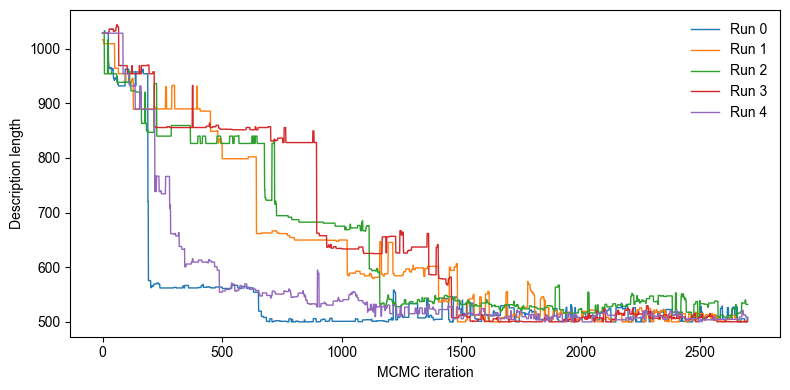

In [2]:
plt.figure(figsize=(8,4))

for i, chain in enumerate(chains):
    plt.plot(chain, lw=1, label=f"Run {i}")

plt.xlabel("MCMC iteration")
plt.ylabel("Description length")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

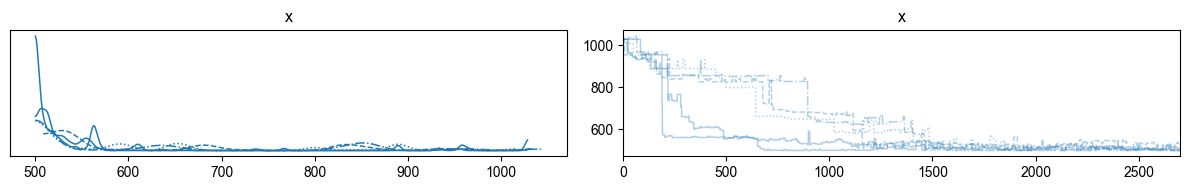

In [3]:
az.plot_trace(idata)
plt.tight_layout()
plt.show()

5 chains
2700 iterations


/tmp/ipykernel_1247640/1894355142.py:39: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  rhat = float(az.rhat(idata).to_array().values)
/tmp/ipykernel_1247640/1894355142.py:39: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  rhat = float(az.rhat(idata).to_array().values)
/tmp/ipykernel_1247640/1894355142.py:39: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  rhat = float(az.rhat(idata).to_array().values)
/tmp/ipykernel_1247640/1894355142.py:39: DeprecationWarning: Conver

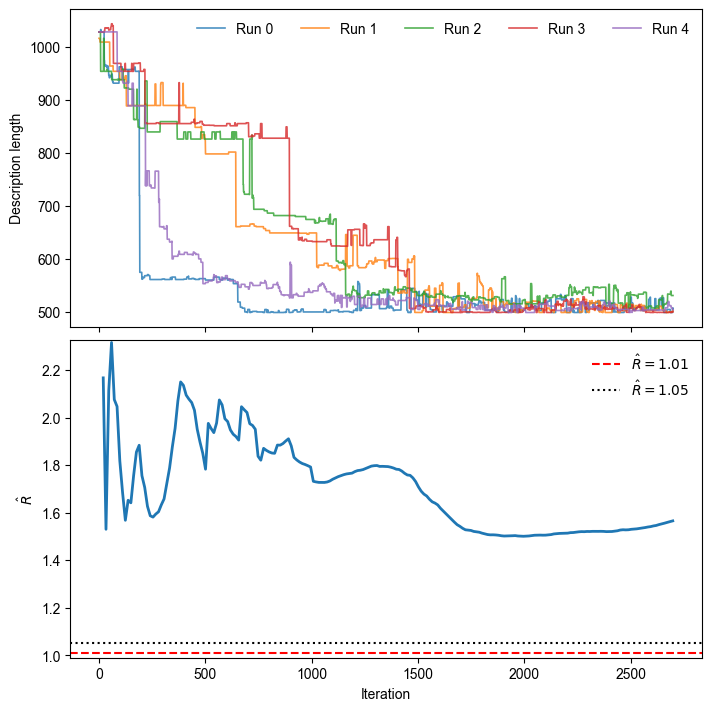

Final R̂ = 1.56607


In [4]:
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import arviz as az

# ------------------------------------------------------------
# Load chains
# ------------------------------------------------------------
files = sorted(glob.glob("dl_evol_run_*.csv"))

chains = []
for f in files:
    df = pd.read_csv(f)
    chains.append(df.iloc[:,0].to_numpy())

# Equalize lengths
n = min(len(c) for c in chains)
chains = np.array([c[:n] for c in chains])

print(f"{chains.shape[0]} chains")
print(f"{chains.shape[1]} iterations")

# ------------------------------------------------------------
# Compute Rhat evolution
# ------------------------------------------------------------
start = max(20, chains.shape[0]*2)    # minimum samples before computing Rhat
step = max(1, n // 200)               # about 200 points on the curve

iters = []
rhats = []

for k in range(start, n+1, step):

    subset = chains[:, :k]

    idata = az.convert_to_inference_data(subset)

    rhat = float(az.rhat(idata).to_array().values)

    iters.append(k)
    rhats.append(rhat)




fig, (ax1, ax2) = plt.subplots(
    2, 1,
    figsize=(7, 7),
    sharex=True,
    constrained_layout=True
)

# ------------------------------------------------------------
# Top: MCMC chains
# ------------------------------------------------------------
for i, chain in enumerate(chains):
    ax1.plot(chain, lw=1.2, alpha=0.8, label=f"Run {i}")

ax1.set_ylabel("Description length")
ax1.legend(frameon=False, ncol=len(chains), loc="upper right")

# ------------------------------------------------------------
# Bottom: Rhat evolution
# ------------------------------------------------------------
ax2.plot(iters, rhats, lw=2)

ax2.axhline(1.01, ls="--", color="red", label=r"$\hat{R}=1.01$")
ax2.axhline(1.05, ls=":", color="black", label=r"$\hat{R}=1.05$")

ax2.set_xlabel("Iteration")
ax2.set_ylabel(r"$\hat{R}$")
ax2.set_ylim(0.99, max(1.1, max(rhats) + 0.01))
ax2.legend(frameon=False)
plt.savefig('gelman-rubin.pdf',dpi=300)
plt.show()


print(f"Final R̂ = {rhats[-1]:.5f}")

In [5]:
# DL true model

In [6]:
# Imports
import pandas as pd
pd.set_option("mode.copy_on_write", False)
import numpy as np
import matplotlib.pyplot as plt
import sys
import warnings
#import gc
#warnings.filterwarnings('ignore')
#gc.disable()
from copy import deepcopy,copy
#from ipywidgets import IntProgress
#from itertools import chain
from IPython.display import display
from datetime import datetime
import pickle
import os
#from sympy import sympify,latex,Float
import random
from math import ceil,sqrt
#import seaborn as sbrn
from scipy.optimize import curve_fit
from scipy.stats import bootstrap
# Catch stout
#from io import StringIO 
import sys
import pynumdiff
import traceback
import gc

# Import Machine Scientist
from importlib.machinery import SourceFileLoader
# Get the absolute path of the script's directory
script_dir = os.getcwd()
# Define the relative path to the module
relative_module_path = "../I-BMS-2d/machinescientist_ode.py"
path = os.path.join(script_dir, relative_module_path)
ms_ode = SourceFileLoader("ms_ode", path).load_module()

true = ('(x * (_a0_ + (_a1_ * y)))','(x * (_a0_ + (_a1_ * y)))')
file='../Lotka-Volterra/noise_data/1.0_0.csv'
data=pd.read_csv(file)
XLABS = ['x','y']
params = 8
x={}
y={}
dx = {}

dy = {}

x['d0']=deepcopy(data)
y['d0']=deepcopy(data)
y['d0'].x=deepcopy(x['d0'].y)
y['d0'].y=deepcopy(x['d0'].x)

h = x['d0'].t.to_numpy()[1] - x['d0'].t.to_numpy()[0]

par = [2, 21, 21]
x_hat, dxdt_hat = pynumdiff.linear_model.polydiff(
        x['d0'].x, h, par, options=None)
y_hat, dydt_hat = pynumdiff.linear_model.polydiff(
        x['d0'].y, h, par, options=None)

dx['d0'] = [ pd.DataFrame(data={'x':x_hat,'y':y_hat}),
            pd.DataFrame(data={'x':dxdt_hat,'y':dydt_hat})]

dy['d0'] = [ pd.DataFrame(data={'x':y_hat,'y':x_hat}),
            pd.DataFrame(data={'x':dydt_hat,'y':dxdt_hat})]
true_x=ms_ode.from_string_model(x,dx,None,true[0],2,8,['x','y'],silence=True)

true_y=ms_ode.from_string_model(y,dy,None,true[1],2,8,['x','y'],silence=True)
true_x.fy,true_y.fy=true_y,true_x
true_x.get_bic(reset=True,fit=True)
true_x.get_energy(reset=True)

print(true_x.E,true_x.par_values,true_y.par_values)
print(np.min(chains))

2026-07-21 17:44:20,880 [INFO] 
Limited Total Variation Regularization Support Detected! 
---> CVXPY is not installed. 
---> Many Total Variation Methods require CVXPY including: 
---> velocity, acceleration, jerk, jerk_sliding, smooth_acceleration
---> Please install CVXPY to use these methods.
---> Recommended to also install MOSEK and obtain a MOSEK license.
You can still use: total_variation_regularization.iterative_velocity

2026-07-21 17:44:20,881 [INFO] 
Limited Linear Model Support Detected! 
---> PYCHEBFUN is not installed. 
---> Install pychebfun to use chebfun derivatives (https://github.com/pychebfun/pychebfun/) 
You can still use other methods 

2026-07-21 17:44:20,881 [INFO] 
Limited Linear Model Support Detected! 
---> CVXPY is not installed. 
---> Install CVXPY to use lineardiff derivatives 
You can still use other methods 

<lambdifygenerated-41>:2: RuntimeWarning: overflow encountered in scalar multiply
  return x*(_a0_ + _a1_*y)
<lambdifygenerated-42>:2: RuntimeWarni

499.594173434136 {'d0': {'_a0_': 0.0997814474471041, '_a1_': -0.01997710205252369}} {'d0': {'_a0_': -0.4022913401967123, '_a1_': 0.020013783836211458}}
499.594081882981
